<a href="https://colab.research.google.com/github/Raulfb04/Simulaci-n-1/blob/main/Examen_3er_Pacial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Programa 1: Línea de espera con 2 servidores en paralelo

## Objetivo

Simular un sistema de línea de espera con dos servidores en paralelo utilizando el enfoque de eventos discretos propuesto por Sheldon Ross.

En este modelo, los clientes llegan a un sistema con una sola fila. Si alguno de los servidores está libre, el cliente entra inmediatamente a servicio. Si ambos servidores están ocupados, el cliente espera en la cola hasta que alguno de los servidores termine su servicio.

## Descripción del sistema

El sistema tiene:

- Una sola línea de espera.
- Dos servidores en paralelo.
- Tiempos entre llegadas aleatorios.
- Tiempos de servicio aleatorios para cada servidor.
- Una lista de eventos formada por:
  - `tA`: tiempo de la próxima llegada.
  - `t1`: tiempo de terminación del servicio en el servidor 1.
  - `t2`: tiempo de terminación del servicio en el servidor 2.

La simulación avanza de evento en evento. En cada paso se identifica cuál de los tres tiempos es el menor y se actualiza el estado del sistema.

In [22]:
# Importamos las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fijamos una semilla para que los resultados sean reproducibles
np.random.seed(123)

# Parámetros del sistema
lambda_llegadas = 4   # tasa promedio de llegadas
mu1 = 6               # tasa promedio de servicio del servidor 1
mu2 = 6               # tasa promedio de servicio del servidor 2

# Número de clientes que deseamos simular
N_clientes = 1000

# Valor muy grande para representar infinito
INF = float("inf")

## Generación de variables aleatorias

Para simular el sistema se generan tiempos aleatorios usando distribuciones exponenciales.

El tiempo entre llegadas se modela como:

$$
T \sim Exp(\lambda)
$$

y los tiempos de servicio como:

$$
Y_1 \sim Exp(\mu_1)
$$

$$
Y_2 \sim Exp(\mu_2)
$$

donde:

- $\lambda$ representa la tasa de llegadas.
- $\mu_1$ representa la tasa de servicio del servidor 1.
- $\mu_2$ representa la tasa de servicio del servidor 2.


En una distribución exponencial se cumple que:

$$
E[X]=\frac{1}{\lambda}
$$

Por esta razón, en Python utilizamos:

```python
np.random.exponential(1/lambda)


In [23]:
def generar_llegada(lam):
    """
    Genera un tiempo entre llegadas con distribución exponencial.
    """
    return np.random.exponential(1 / lam)


def generar_servicio(mu):
    """
    Genera un tiempo de servicio con distribución exponencial.
    """
    return np.random.exponential(1 / mu)

In [24]:
# ==========================================
# Inicialización de variables de simulación
# ==========================================

# Reloj de simulación
t = 0

# Número de clientes en el sistema
N = 0

# Estados de los servidores
# 0 = libre
# 1 = ocupado

estado1 = 0
estado2 = 0

# Próximos eventos

tA = generar_llegada(lambda_llegadas)
t1 = INF
t2 = INF

# Cola de espera

cola = []

# Estadísticas

clientes_atendidos = 0

tiempo_espera_total = 0
tiempo_sistema_total = 0

# Registro de tiempos de llegada

llegadas_sistema = []

# Para gráficas

historial_t = []
historial_N = []

print("Sistema inicializado correctamente")

Sistema inicializado correctamente


## Ciclo principal de simulación

La simulación se ejecuta hasta completar el número deseado de clientes atendidos.

En cada iteración se identifica el evento más próximo:

$$
\min(t_A,t_1,t_2)
$$

Los posibles eventos son:

1. Llegada de un cliente.
2. Fin de servicio en el servidor 1.
3. Fin de servicio en el servidor 2.

Dependiendo del evento ocurrido se actualiza el estado del sistema y la lista de eventos futuros.

In [25]:
area_N = 0

In [26]:
# ==========================================
# Ciclo principal de simulación
# ==========================================

while clientes_atendidos < N_clientes:

    # Guardamos el tiempo anterior para actualizar áreas
    tiempo_anterior = t

    # Determinamos cuál es el siguiente evento
    siguiente_evento = min(tA, t1, t2)

    # Avanzamos el reloj de simulación
    t = siguiente_evento

    # Actualizamos el área bajo la curva N(t)
    area_N += N * (t - tiempo_anterior)

    # Guardamos historial para graficar
    historial_t.append(t)
    historial_N.append(N)

    # ======================================
    # Caso 1: ocurre una llegada
    # ======================================

    if tA <= t1 and tA <= t2:

        N += 1

        # Guardamos la hora de llegada del cliente
        llegadas_sistema.append(t)

        # Programamos la siguiente llegada
        tA = t + generar_llegada(lambda_llegadas)

        # Si el servidor 1 está libre, el cliente entra al servidor 1
        if estado1 == 0:
            estado1 = 1
            tiempo_servicio = generar_servicio(mu1)
            t1 = t + tiempo_servicio

        # Si el servidor 1 está ocupado pero el servidor 2 está libre,
        # el cliente entra al servidor 2
        elif estado2 == 0:
            estado2 = 1
            tiempo_servicio = generar_servicio(mu2)
            t2 = t + tiempo_servicio

        # Si ambos servidores están ocupados, el cliente se forma
        else:
            cola.append(t)

    # ======================================
    # Caso 2: termina servicio en servidor 1
    # ======================================

    elif t1 <= tA and t1 <= t2:

        clientes_atendidos += 1
        N -= 1

        # El cliente que sale corresponde al primero que llegó
        llegada_cliente = llegadas_sistema.pop(0)
        tiempo_sistema_total += t - llegada_cliente

        # Si hay clientes esperando, entra el primero de la cola
        if len(cola) > 0:
            llegada_cola = cola.pop(0)
            tiempo_espera_total += t - llegada_cola

            tiempo_servicio = generar_servicio(mu1)
            t1 = t + tiempo_servicio

        # Si no hay cola, el servidor queda libre
        else:
            estado1 = 0
            t1 = INF

    # ======================================
    # Caso 3: termina servicio en servidor 2
    # ======================================

    else:

        clientes_atendidos += 1
        N -= 1

        # El cliente que sale corresponde al primero que llegó
        llegada_cliente = llegadas_sistema.pop(0)
        tiempo_sistema_total += t - llegada_cliente

        # Si hay clientes esperando, entra el primero de la cola
        if len(cola) > 0:
            llegada_cola = cola.pop(0)
            tiempo_espera_total += t - llegada_cola

            tiempo_servicio = generar_servicio(mu2)
            t2 = t + tiempo_servicio

        # Si no hay cola, el servidor queda libre
        else:
            estado2 = 0
            t2 = INF

print("Simulación terminada")
print("Clientes atendidos:", clientes_atendidos)

Simulación terminada
Clientes atendidos: 1000


In [27]:
# ==========================================
# Resultados de la simulación
# ==========================================

tiempo_promedio_sistema = tiempo_sistema_total / clientes_atendidos
tiempo_promedio_espera = tiempo_espera_total / clientes_atendidos
numero_promedio_sistema = area_N / t

print("RESULTADOS DE LA SIMULACIÓN")
print("----------------------------")
print(f"Tiempo total simulado: {t:.4f}")
print(f"Clientes atendidos: {clientes_atendidos}")
print(f"Tiempo promedio en el sistema: {tiempo_promedio_sistema:.4f}")
print(f"Tiempo promedio de espera en cola: {tiempo_promedio_espera:.4f}")
print(f"Número promedio de clientes en el sistema: {numero_promedio_sistema:.4f}")

RESULTADOS DE LA SIMULACIÓN
----------------------------
Tiempo total simulado: 261.4042
Clientes atendidos: 1000
Tiempo promedio en el sistema: 0.1817
Tiempo promedio de espera en cola: 0.0185
Número promedio de clientes en el sistema: 0.6956


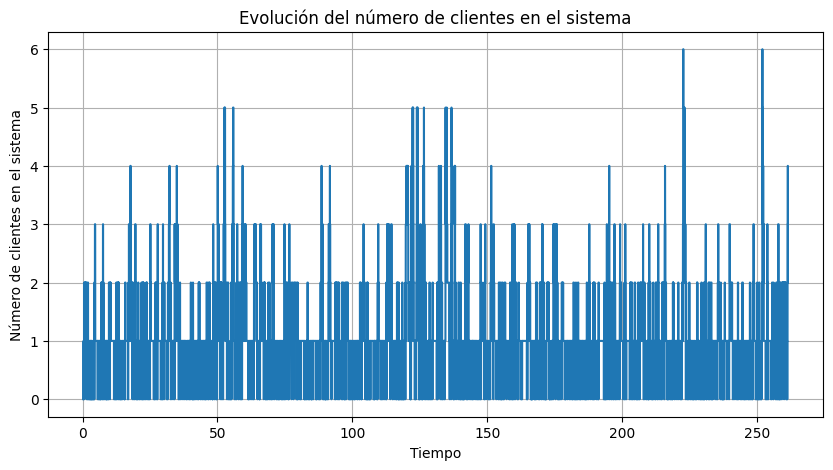

In [28]:
plt.figure(figsize=(10,5))
plt.step(historial_t, historial_N, where="post")
plt.xlabel("Tiempo")
plt.ylabel("Número de clientes en el sistema")
plt.title("Evolución del número de clientes en el sistema")
plt.grid(True)
plt.show()

## Conclusión

Se implementó una simulación de eventos discretos para una línea de espera con dos servidores en paralelo.

El programa actualiza el sistema de acuerdo con el evento más próximo entre llegada, salida del servidor 1 o salida del servidor 2. A partir de la simulación se obtuvieron medidas de desempeño como el tiempo promedio en el sistema, el tiempo promedio de espera y el número promedio de clientes dentro del sistema.

Este tipo de simulación permite estudiar sistemas de espera cuando el comportamiento exacto puede ser difícil de analizar de forma directa.


# Programa 2: Variables antitéticas

## Objetivo

Estimar la integral:

$$
I=\int_0^1 e^{x^2}\,dx
$$

utilizando el método de Monte Carlo ordinario y compararlo con el método de variables antitéticas.

La idea de las variables antitéticas consiste en usar pares de números aleatorios relacionados:

$$
U
$$

y

$$
1-U
$$

donde:

$$
U \sim Uniforme(0,1)
$$

De esta forma, se busca reducir la varianza del estimador.

In [29]:
# ==============================
# Programa 2: Variables antitéticas
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(123)

# Número de simulaciones
n = 10000

# Función a integrar
def g(x):
    return np.exp(x**2)

## Estimación por Monte Carlo ordinario

Para estimar:

$$
I=\int_0^1 e^{x^2}\,dx
$$

generamos valores aleatorios:

$$
U_1,U_2,\ldots,U_n \sim Uniforme(0,1)
$$

y usamos el estimador:

$$
\hat{I}_{MC}=\frac{1}{n}\sum_{i=1}^{n} e^{U_i^2}
$$


In [30]:
# Monte Carlo ordinario

U = np.random.uniform(0, 1, n)

estimaciones_mc = g(U)

I_mc = np.mean(estimaciones_mc)
var_mc = np.var(estimaciones_mc, ddof=1)
error_mc = np.sqrt(var_mc / n)

print("Monte Carlo ordinario")
print("----------------------")
print(f"Estimación de la integral: {I_mc:.6f}")
print(f"Varianza muestral: {var_mc:.6f}")
print(f"Error estándar: {error_mc:.6f}")

Monte Carlo ordinario
----------------------
Estimación de la integral: 1.458724
Varianza muestral: 0.220493
Error estándar: 0.004696


## Estimación mediante variables antitéticas

En lugar de utilizar únicamente los valores:

$$
U_i
$$

también utilizamos sus variables antitéticas:

$$
1-U_i
$$

Para cada observación se construye:

$$
Y_i=\frac{e^{U_i^2}+e^{(1-U_i)^2}}{2}
$$

y el estimador de la integral es:

$$
\hat{I}_{A}=\frac{1}{n}\sum_{i=1}^{n}Y_i
$$

El objetivo es reducir la variabilidad del estimador respecto al método Monte Carlo tradicional.

In [31]:
# Variables antitéticas

U = np.random.uniform(0, 1, n)

Y = (g(U) + g(1 - U)) / 2

I_ant = np.mean(Y)
var_ant = np.var(Y, ddof=1)
error_ant = np.sqrt(var_ant / n)

print("Variables antitéticas")
print("----------------------")
print(f"Estimación de la integral: {I_ant:.6f}")
print(f"Varianza muestral: {var_ant:.6f}")
print(f"Error estándar: {error_ant:.6f}")

Variables antitéticas
----------------------
Estimación de la integral: 1.461970
Varianza muestral: 0.027854
Error estándar: 0.001669


## Comparación de resultados

Finalmente se comparan ambos métodos para analizar si las variables antitéticas lograron reducir la varianza de la estimación.

In [32]:
# Comparación

resultados = pd.DataFrame({
    "Método": ["Monte Carlo", "Antitéticas"],
    "Estimación": [I_mc, I_ant],
    "Varianza": [var_mc, var_ant],
    "Error estándar": [error_mc, error_ant]
})

resultados

,Método,Estimación,Varianza,Error estándar
0,Monte Carlo,1.458724,0.220493,0.004696
1,Antitéticas,1.461970,0.027854,0.001669


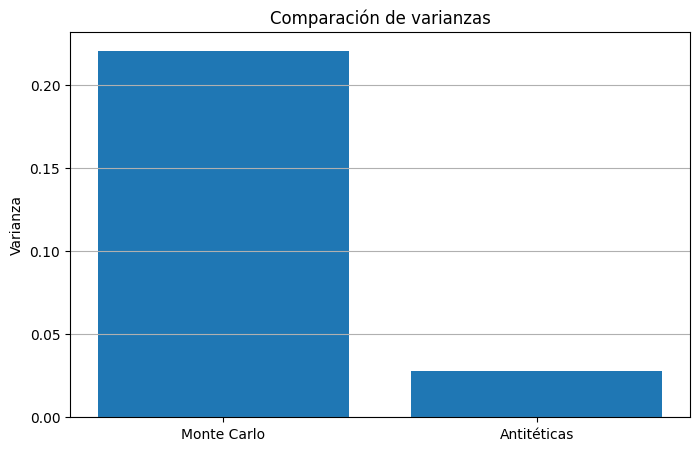

In [33]:
# Gráfica comparativa

plt.figure(figsize=(8,5))

plt.bar(
    ["Monte Carlo", "Antitéticas"],
    [var_mc, var_ant]
)

plt.ylabel("Varianza")
plt.title("Comparación de varianzas")
plt.grid(axis="y")

plt.show()

## Conclusión

Se estimó la integral

$$
I=\int_0^1 e^{x^2}\,dx
$$

mediante dos técnicas de simulación.

El método de variables antitéticas utiliza pares de observaciones relacionadas para disminuir la variabilidad de la estimación. Al comparar las varianzas obtenidas se puede observar si la técnica logra producir estimadores más precisos que el método Monte Carlo ordinario.

La reducción de la varianza implica una mejora en la precisión sin necesidad de aumentar el número de simulaciones realizadas.

# Programa 3: Técnicas de remuestreo Bootstrap y Jackknife

## Objetivo

Aplicar las técnicas de remuestreo Bootstrap y Jackknife para estimar parámetros estadísticos a partir de una muestra de datos observados.

Se utilizará la siguiente muestra de tiempos de entrega:

$$
\{35,42,38,40,45,37,39,41,44,36,43,40\}
$$

Mediante Bootstrap se generarán múltiples muestras con reemplazo para estimar la distribución de la media muestral.

Posteriormente se aplicará la técnica Jackknife, eliminando una observación a la vez para obtener una estimación de la varianza y del error estándar.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(123)

# Datos originales

datos = np.array([35,42,38,40,45,37,39,41,44,36,43,40])

n = len(datos)

print("Número de observaciones:", n)
print("Media muestral:", np.mean(datos))

Número de observaciones: 12
Media muestral: 40.0


## Método Bootstrap

La técnica Bootstrap consiste en generar muestras de tamaño n con reemplazo a partir de la muestra original.

Para este ejercicio se generarán:

$$
B=1000
$$

muestras Bootstrap.

Para cada muestra se calculará la media muestral.

In [35]:
# Número de remuestras Bootstrap

B = 1000

# Almacenará las medias Bootstrap

medias_bootstrap = []

for i in range(B):

    muestra_boot = np.random.choice(
        datos,
        size=n,
        replace=True
    )

    medias_bootstrap.append(np.mean(muestra_boot))

medias_bootstrap = np.array(medias_bootstrap)

print("Bootstrap completado")

Bootstrap completado


In [36]:
# Estadísticas Bootstrap

media_boot = np.mean(medias_bootstrap)

desv_boot = np.std(
    medias_bootstrap,
    ddof=1
)

p025 = np.percentile(
    medias_bootstrap,
    2.5
)

p975 = np.percentile(
    medias_bootstrap,
    97.5
)

print("RESULTADOS BOOTSTRAP")
print("---------------------")
print(f"Media Bootstrap: {media_boot:.4f}")
print(f"Desviación estándar: {desv_boot:.4f}")
print(f"Percentil 2.5%: {p025:.4f}")
print(f"Percentil 97.5%: {p975:.4f}")

print(f"\nIC 95%: [{p025:.4f}, {p975:.4f}]")

RESULTADOS BOOTSTRAP
---------------------
Media Bootstrap: 40.0090
Desviación estándar: 0.8653
Percentil 2.5%: 38.4167
Percentil 97.5%: 41.6667

IC 95%: [38.4167, 41.6667]


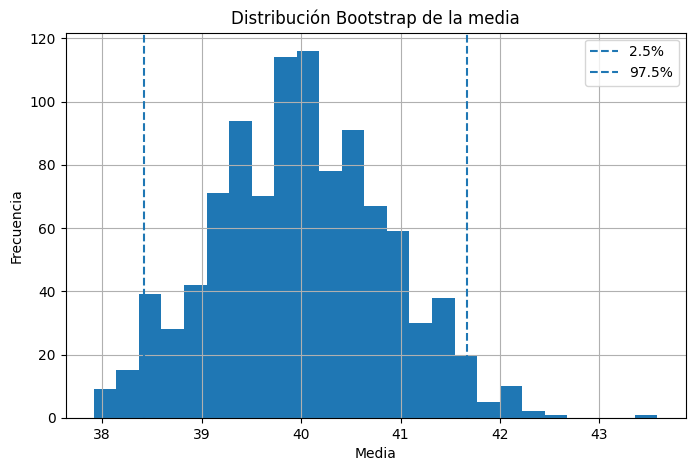

In [37]:
# Histograma Bootstrap

plt.figure(figsize=(8,5))

plt.hist(
    medias_bootstrap,
    bins=25
)

plt.axvline(
    p025,
    linestyle="--",
    label="2.5%"
)

plt.axvline(
    p975,
    linestyle="--",
    label="97.5%"
)

plt.title("Distribución Bootstrap de la media")
plt.xlabel("Media")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)

plt.show()

## Método Jackknife

La técnica Jackknife consiste en eliminar una observación de la muestra original y calcular el estadístico de interés utilizando las n−1 observaciones restantes.

Con una muestra de tamaño:

$$
n=12
$$

se generan 12 remuestras Jackknife.

Para cada remuestra se calcula la media.

In [38]:
# Remuestras Jackknife

medias_jack = []

for i in range(n):

    muestra_jack = np.delete(
        datos,
        i
    )

    medias_jack.append(
        np.mean(muestra_jack)
    )

medias_jack = np.array(medias_jack)

medias_jack

array([40.45454545, 39.81818182, 40.18181818, 40.        , 39.54545455,
       40.27272727, 40.09090909, 39.90909091, 39.63636364, 40.36363636,
       39.72727273, 40.        ])

In [39]:
# Promedio Jackknife

theta_barra = np.mean(
    medias_jack
)

# Varianza Jackknife

var_jack = (
    (n - 1) / n
) * np.sum(
    (medias_jack - theta_barra)**2
)

error_jack = np.sqrt(
    var_jack
)

print("RESULTADOS JACKKNIFE")
print("---------------------")
print(f"Promedio Jackknife: {theta_barra:.4f}")
print(f"Varianza Jackknife: {var_jack:.6f}")
print(f"Error estándar Jackknife: {error_jack:.6f}")

RESULTADOS JACKKNIFE
---------------------
Promedio Jackknife: 40.0000
Varianza Jackknife: 0.833333
Error estándar Jackknife: 0.912871


In [40]:
# Tabla resumen

resumen = pd.DataFrame({
    "Método": ["Bootstrap", "Jackknife"],
    "Estimación": [
        media_boot,
        theta_barra
    ],
    "Medida de dispersión": [
        desv_boot,
        error_jack
    ]
})

resumen

,Método,Estimación,Medida de dispersión
0,Bootstrap,40.009,0.865280
1,Jackknife,40.000,0.912871


## Conclusión

Se aplicaron las técnicas de remuestreo Bootstrap y Jackknife utilizando una muestra de 12 tiempos de entrega.

Mediante Bootstrap se generaron 1000 muestras con reemplazo, obteniendo una distribución empírica de la media muestral. A partir de esta distribución se calcularon la media Bootstrap, la desviación estándar y un intervalo de confianza del 95%.

Posteriormente se aplicó la técnica Jackknife eliminando una observación a la vez. Con las remuestras obtenidas se estimó la varianza y el error estándar de la media.

Ambos métodos permiten estudiar la variabilidad de un estimador sin necesidad de conocer la distribución poblacional original, siendo herramientas ampliamente utilizadas en simulación y análisis estadístico.